## Demo

In [1]:
import SimpleITK as sitk
import matplotlib.pyplot as plt
import torch
import numpy as np
from synthnormaug import SyntheticGMMAugmentation

### load an example of a z-score normalized image, WMH mask and Synthseg image

In [2]:
flair = torch.from_numpy(sitk.GetArrayFromImage(sitk.ReadImage("example_flair.nii.gz")))
wmh = torch.from_numpy(sitk.GetArrayFromImage(sitk.ReadImage("example_wmh.nii.gz")))
synthseg = torch.from_numpy(sitk.GetArrayFromImage(sitk.ReadImage("example_synthseg.nii.gz")))
mask = torch.from_numpy(sitk.GetArrayFromImage(sitk.ReadImage("example_brainmask.nii.gz")))

In [3]:
data = {'FLAIR':flair, 'label':wmh, 'synthseg':synthseg}

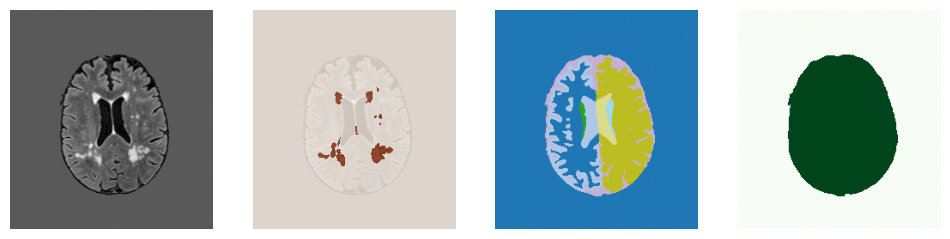

In [4]:
islice = 140
fig, axs = plt.subplots(1, 4, figsize=(12, 3))

axs[0].imshow(flair[islice], origin='lower', cmap='gray')
axs[1].imshow(flair[islice], origin='lower', cmap='gray')
axs[1].imshow(wmh[islice], origin='lower', cmap='Oranges', alpha=0.8)
axs[2].imshow(synthseg[islice], origin='lower', cmap='tab20')
axs[3].imshow(mask[islice], origin='lower', cmap='Greens')
for ax in axs:
    ax.axis('off')

### example SynthNorm augmentation

In [5]:
from synthnormaug.synthetic_intensity_augmentation import SyntheticGMMAugmentation

In [6]:
gmm_weight_path = "synthnormaug/synthetic_intensity_augmentation/gmm_params"
synthnorm = SyntheticGMMAugmentation(
    mean_z_temperature_cap=10,
    std_z_temperature_cap=10,
    std_weighting=0.5,
    keys=['FLAIR'],
    wmh_mask='label',
    gmm_weight_path=gmm_weight_path
)

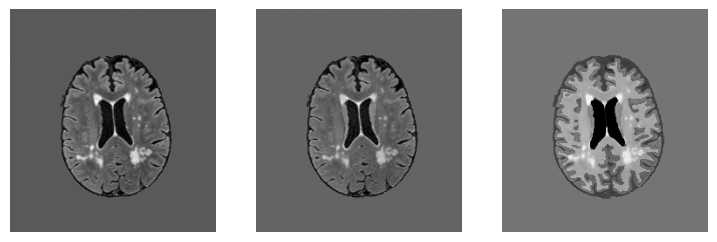

In [9]:
example_1 = synthnorm(data)
example_2 = synthnorm(data)

fig, axs = plt.subplots(1, 3, figsize=(9, 3))

axs[0].imshow(flair[islice], origin='lower', cmap='gray')
axs[1].imshow(example_1['FLAIR'][islice], origin='lower', cmap='gray')
axs[2].imshow(example_2['FLAIR'][islice], origin='lower', cmap='gray')

for ax in axs:
    ax.axis('off')

### example Perlin Bias Field

In [10]:
from synthnormaug import PerlinBiasField

In [14]:
shape = np.array(flair.shape)

In [15]:
# strong bias field
min_range=(0.35, 0.75)
max_range=(1.25, 1.85)
perlin_bf = PerlinBiasField(
    shape=shape//2,
    base_res=shape//4,
    res_scales=[1,1,2,2,3,3,4,4],
    min_range=min_range,
    max_range=max_range,
    return_field=True,
    mask_at_0=False,
    resample_factor=2
)

In [16]:
img1, bf1 = perlin_bf(flair, mask)
img2, bf2 = perlin_bf(flair, mask)
img1, bf1, img2, bf2 = img1.squeeze(), bf1.squeeze(), img2.squeeze(), bf2.squeeze()

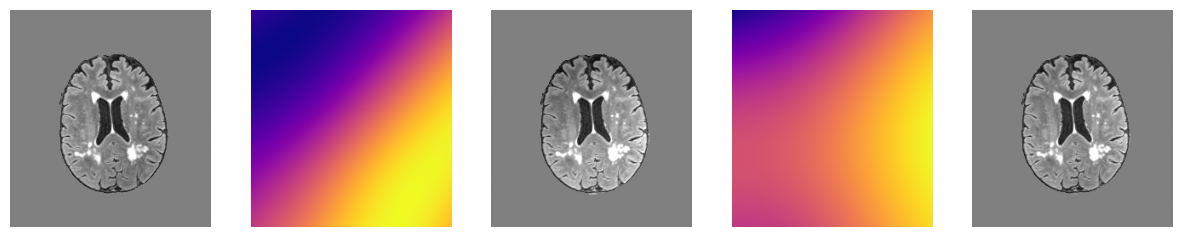

In [17]:
fig, axs = plt.subplots(1, 5, figsize=(15, 3))

axs[0].imshow(flair[islice], origin='lower', cmap='gray', vmin=-3, vmax=3)
axs[1].imshow(bf1[islice], origin='lower', cmap='plasma')
axs[2].imshow(img1[islice], origin='lower', cmap='gray', vmin=-3, vmax=3)
axs[3].imshow(bf2[islice], origin='lower', cmap='plasma')
axs[4].imshow(img2[islice], origin='lower', cmap='gray', vmin=-3, vmax=3)
for ax in axs:
    ax.axis('off')

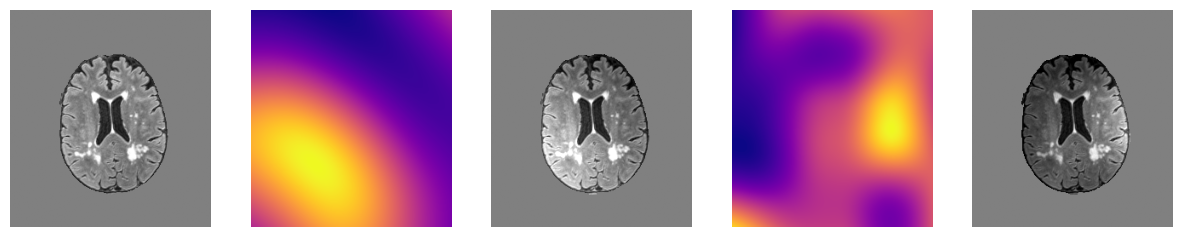

In [72]:
fig, axs = plt.subplots(1, 5, figsize=(15, 3))

axs[0].imshow(flair[islice], origin='lower', cmap='gray', vmin=-3, vmax=3)
axs[1].imshow(bf1[islice], origin='lower', cmap='plasma')
axs[2].imshow(img1[islice], origin='lower', cmap='gray', vmin=-3, vmax=3)
axs[3].imshow(bf2[islice], origin='lower', cmap='plasma')
axs[4].imshow(img2[islice], origin='lower', cmap='gray', vmin=-3, vmax=3)
for ax in axs:
    ax.axis('off')

### example of full augmentation pipeline

In [ ]:
fig, axs = plt.subplots(9, 6, figsize=(6, 9))

flair1[data1['brainmask'] == 0] = flair1.min()
flair2[data2['brainmask'] == 0] = flair2.min()
plot_3_on_axis(flair1, axs[0][0:3])
plot_3_on_axis(flair2, axs[0][3:6])
axs[0][1].set_title("example 1")
axs[0][4].set_title("example 2")

plot_3_on_axis(B1_p4, axs[1][0:3], vmin=0.4, vmax=1.6, cmap=cmap)
plot_3_on_axis(B2_p4, axs[1][3:6], vmin=0.4, vmax=1.6, cmap=cmap)

plot_3_on_axis(I1_p4, axs[2][0:3])
plot_3_on_axis(I2_p4, axs[2][3:6])

plot_3_on_axis(B1_p3, axs[3][0:3], vmin=0.4, vmax=1.6, cmap=cmap)
plot_3_on_axis(B2_p3, axs[3][3:6], vmin=0.4, vmax=1.6, cmap=cmap)

plot_3_on_axis(I1_p3, axs[4][0:3])
plot_3_on_axis(I2_p3, axs[4][3:6])

plot_3_on_axis(B1_p2, axs[5][0:3], vmin=0.4, vmax=1.6, cmap=cmap)
plot_3_on_axis(B2_p2, axs[5][3:6], vmin=0.4, vmax=1.6, cmap=cmap)

plot_3_on_axis(I1_p2, axs[6][0:3])
plot_3_on_axis(I2_p2, axs[6][3:6])

plot_3_on_axis(B1_p1, axs[7][0:3], vmin=0.4, vmax=1.6, cmap=cmap)
plot_3_on_axis(B2_p1, axs[7][3:6], vmin=0.4, vmax=1.6, cmap=cmap)

plot_3_on_axis(I1_p1, axs[8][0:3])
plot_3_on_axis(I2_p1, axs[8][3:6])

plt.subplots_adjust(wspace=0.0, hspace=0.5)
plt.tight_layout(pad=0.1)